#SECTION 1: IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#SECTION 2: LOAD DATASET 1

In [4]:
df = pd.read_csv('Data_Feb_2026.csv')
df.head()

,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


#Understanding the Dataset

In [5]:
print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(1375, 5)

Column Names:
Index(['X1', 'X2', 'X3', 'X4', 'Label'], dtype='object')

Data Types:
X1       float64
X2       float64
X3       float64
X4       float64
Label    float64
dtype: object


#Dataset Information

In [7]:
df.info()
#Statistical Summary
df.describe()
#Missing Value Analysis
df.isnull().sum()
#Duplicate Value Analysis
df.duplicated().sum()
#Data Cleaning
df_clean = df.dropna()
print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)
#Verifying Data Cleaning
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1375 non-null   float64
 1   X2      1375 non-null   float64
 2   X3      1375 non-null   float64
 3   X4      1375 non-null   float64
 4   Label   1374 non-null   float64
dtypes: float64(5)
memory usage: 53.8 KB
Original Shape: (1375, 5)
Clean Shape: (1374, 5)


,0
X1,0
X2,0
X3,0
X4,0
Label,0


#Exploratory Data Analysis (EDA)

Distribution of Target Variable

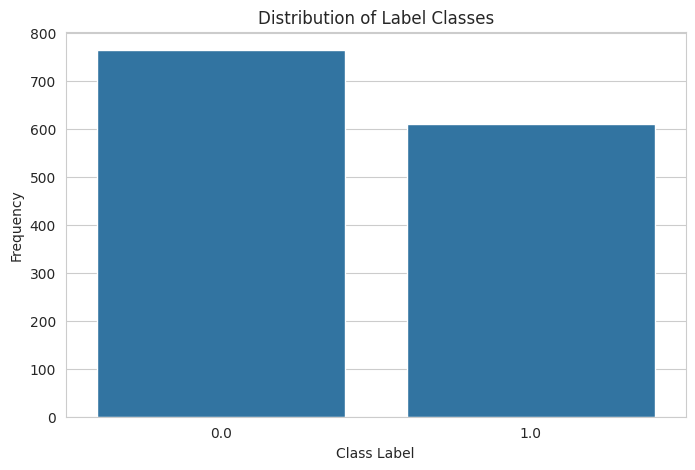

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Label', data=df_clean)
plt.title('Distribution of Label Classes')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.show()

Descriptive Statistics of Clean Data

In [9]:
df_clean.describe()

,X1,X2,X3,X4,Label
count,1374.000000,1374.000000,1374.000000,1374.000000,1374.000000
mean,0.385973,2.014917,1.356035,-1.251131,0.443959
std,3.420128,6.678472,4.527218,2.988971,0.497030
min,-70.000000,-13.773100,-50.000000,-80.000000,0.000000
25%,-1.776400,-1.701475,-1.631525,-2.429950,0.000000
50%,0.496180,2.327950,0.615345,-0.588590,0.000000
75%,2.822625,6.820850,3.174525,0.394810,1.000000
max,6.824800,120.000000,17.927400,2.449500,1.000000


Histograms of Features

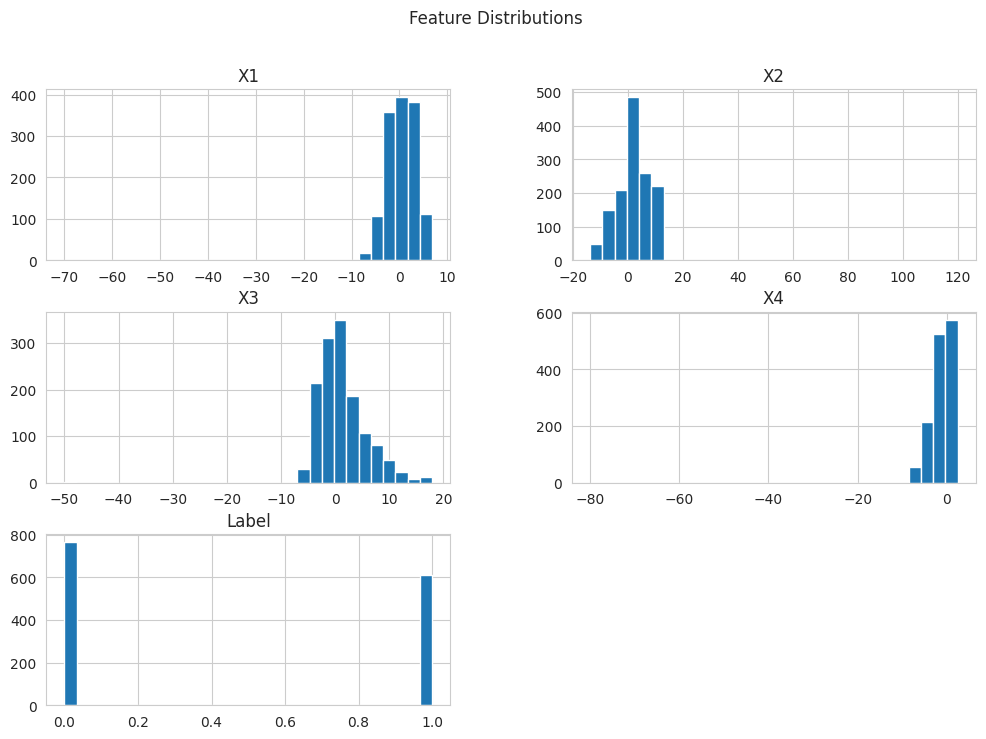

In [10]:
df_clean.hist(figsize=(12,8), bins=30)
plt.suptitle('Feature Distributions')
plt.show()

Outlier Analysis

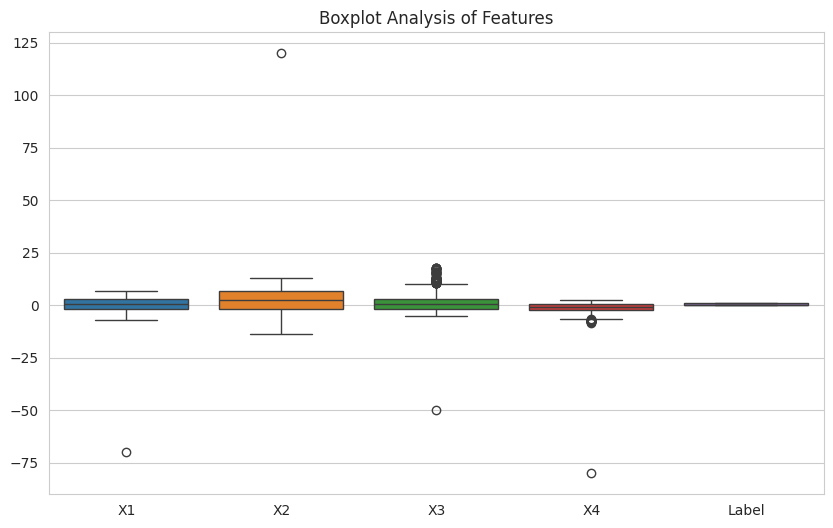

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean)
plt.title('Boxplot Analysis of Features')
plt.show()

Correlation Analysis

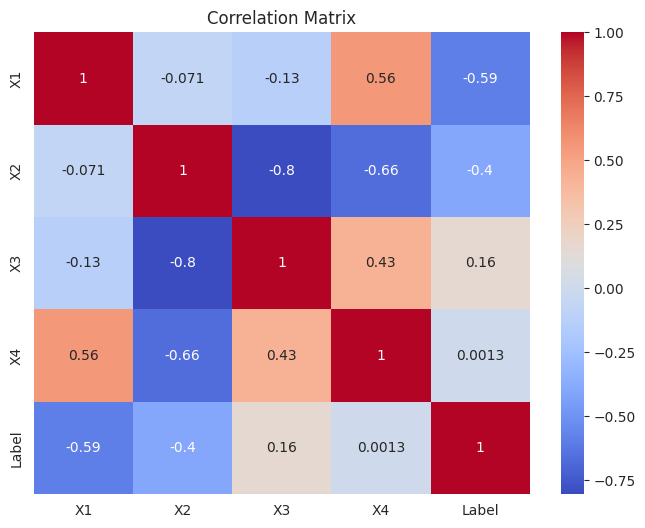

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

#Comparative Analysis of X1 and X4

Distribution of X1

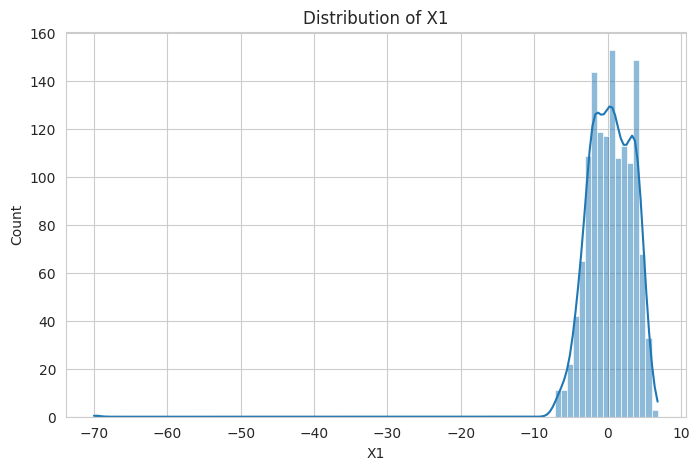

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean['X1'],
    kde=True
)
plt.title('Distribution of X1')
plt.show()

Distribution of X4

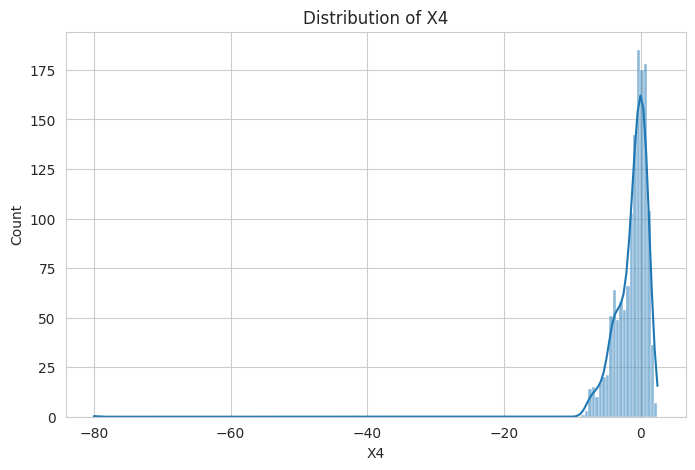

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean['X4'],
    kde=True
)
plt.title('Distribution of X4')
plt.show()

Skewness Analysis

In [15]:
x1_skew = skew(df_clean['X1'])
x4_skew = skew(df_clean['X4'])
print("Skewness of X1 =", x1_skew)
print("Skewness of X4 =", x4_skew)

Skewness of X1 = -6.405224188678892
Skewness of X4 = -13.649939697405095


Boxplot Comparison of X1 and X4

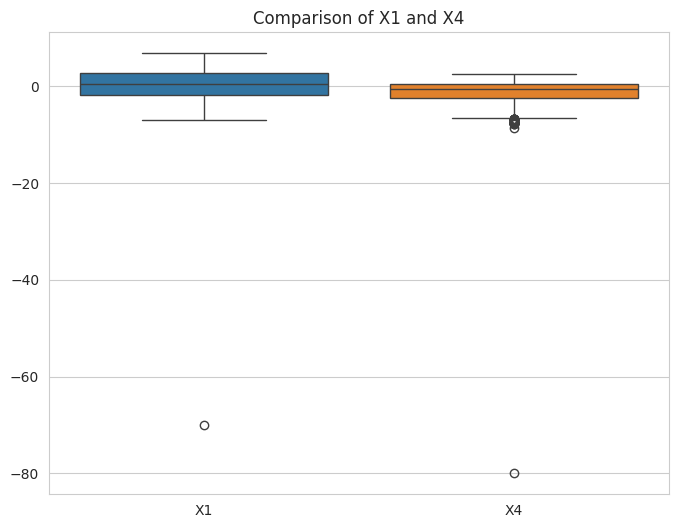

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean[['X1','X4']])
plt.title('Comparison of X1 and X4')
plt.show()

#Class Probability Analysis

In [17]:
label_counts = df_clean['Label'].value_counts()
total = len(df_clean)
p0 = label_counts[0] / total
p1 = label_counts[1] / total
print("P(Class 0) =", p0)
print("P(Class 1) =", p1)

P(Class 0) = 0.5560407569141194
P(Class 1) = 0.44395924308588064


Gini Impurity Calculation

In [18]:
gini = 1 - (p0**2 + p1**2)
print("Gini Impurity =", gini)

Gini Impurity = 0.49371886712898516


Entropy Calculation

In [19]:
entropy = -(p0*np.log2(p0) + p1*np.log2(p1))
print("Entropy =", entropy)

Entropy = 0.9909191720684906


Misclassification Rate

In [20]:
misclassification_rate = 1 - max(p0,p1)
print("Misclassification Rate =", misclassification_rate)

Misclassification Rate = 0.44395924308588064


#Loading Dataset 2

In [21]:
reg_df = pd.read_csv('Task3_Data_TimeSeriesRegression.csv')
reg_df.head()

,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910


Understanding Dataset 2

In [22]:
reg_df.info()
reg_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       1000 non-null   float64
 1   f(t)    1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


,t,f(t)
count,1000.000000,1000.000000
mean,0.029528,276.432619
std,2.912450,490.620460
min,-4.981509,0.000152
25%,-2.571579,3.796317
50%,0.050400,8.999929
75%,2.644340,320.386458
max,4.989894,2092.282079


Visualising the Relationship Between t and f(t)

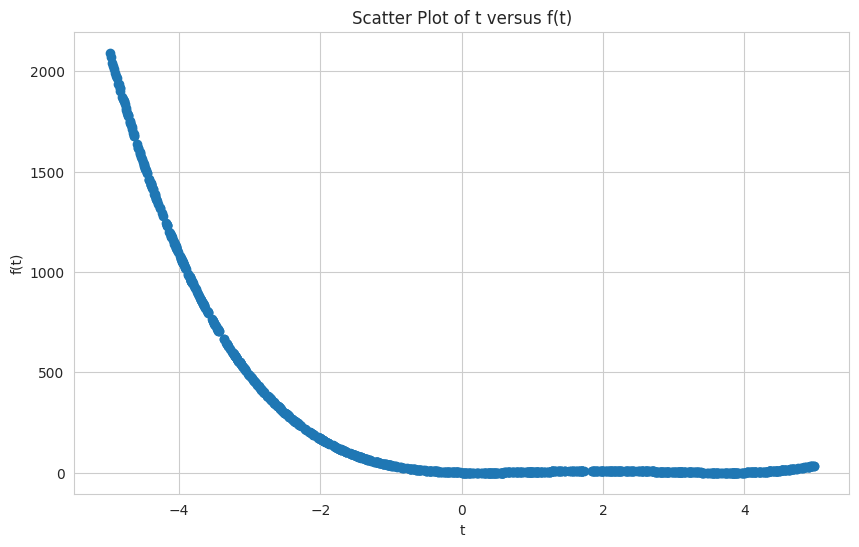

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(
    reg_df['t'],
    reg_df['f(t)']
)
plt.title('Scatter Plot of t versus f(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

Preparing Data for Regression

In [24]:
X = reg_df[['t']]
y = reg_df['f(t)']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Polynomial Feature Engineering

In [25]:
poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

Training the Polynomial Regression Model

In [26]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
#Making Predictions
y_pred = model.predict(X_test_poly)

Evaluating Model Performance

In [27]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 6.343402490660338e-08
MSE = 1.6346417654334867e-14
RMSE = 1.2785310967800067e-07
R² = 1.0


Actual versus Predicted Values

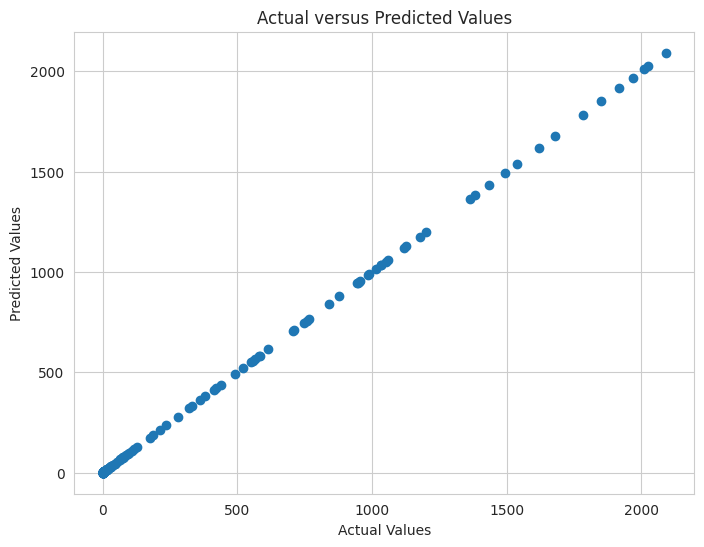

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual versus Predicted Values')
plt.show()

#Residual Analysis

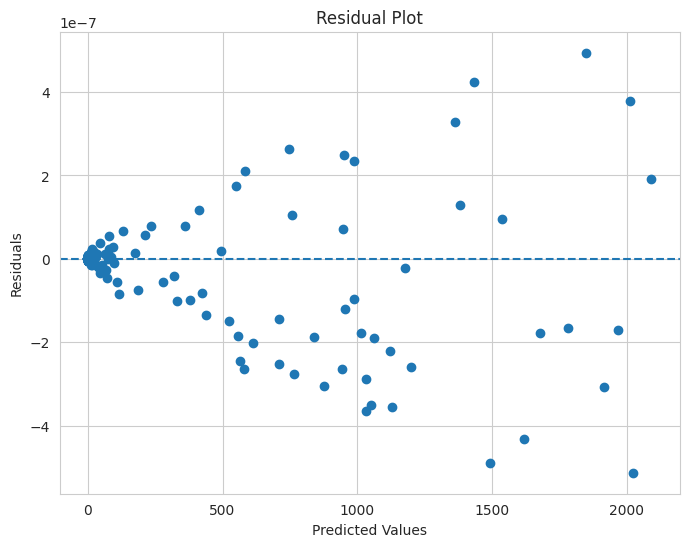

In [29]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

Polynomial Regression Trend

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


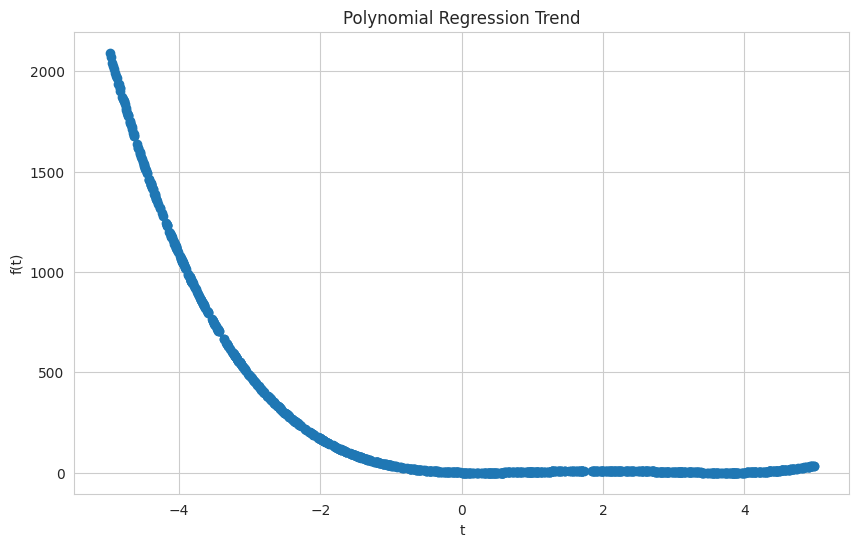

In [30]:
x_range = np.linspace(
    reg_df['t'].min(),
    reg_df['t'].max(),
    500
).reshape(-1,1)
x_poly = poly.transform(x_range)
y_range = model.predict(x_poly)
plt.figure(figsize=(10,6))
plt.scatter(reg_df['t'], reg_df['f(t)'])
plt.plot(x_range, y_range, linewidth=3)
plt.title('Polynomial Regression Trend')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()